In [ ]:
# %pip install --upgrade pandas pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 11.1 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# uncomment below code if not running pandas
# %pip uninstall pandas pyarrow -y
# %pip install pandas pyarrow

Found existing installation: pandas 3.0.2
Uninstalling pandas-3.0.2:
  Successfully uninstalled pandas-3.0.2
Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-3.0.2-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached pyarrow-23.0.1-cp312-cp312-macosx_12_0_arm64.whl.metadata (3.1 kB)
Using cached pandas-3.0.2-cp312-cp312-macosx_11_0_arm64.whl (9.9 MB)
Using cached pyarrow-23.0.1-cp312-cp312-macosx_12_0_arm64.whl (34.2 MB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import pyarrow as pya

print(pd.__version__)
print(pya.__version__)

3.0.2
23.0.1


In [2]:
%pip install nba_api


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
from nba_api.stats.static import teams

def one_dict(list_dict):
    keys=list_dict[0].keys()
    out_dict={key:[] for key in keys}
    for dict_ in list_dict:
        for key, value in dict_.items():
            out_dict[key].append(value)
    return out_dict

nba_teams = teams.get_teams()
nba_teams[0:3]

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970}]

In [5]:
dict_nba_team=one_dict(nba_teams)
df_teams=pd.DataFrame(dict_nba_team)
df_teams.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


In [6]:
df_warriors=df_teams[df_teams['nickname']=='Warriors']

df_warriors


,id,full_name,abbreviation,nickname,city,state,year_founded
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946


In [7]:
id_warriors=df_warriors[['id']].values[0][0]
# we now have an integer that can be used to request the Warriors information 
id_warriors

np.int64(1610612744)

In [10]:
from nba_api.stats.endpoints import leaguegamefinder

gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=id_warriors)
gamefinder

gamefinder.get_json()

'{"resource": "leaguegamefinderparameters", "parameters": {"PlayerOrTeam": "T", "LeagueID": "00", "Season": null, "SeasonType": null, "DateFrom": "", "DateTo": "", "TeamID": "1610612744", "VsTeamID": null, "PlayerID": null, "GameID": null, "Outcome": null, "Location": null, "VsConference": null, "VsDivision": null, "Conference": null, "Division": null, "DraftYear": null, "DraftNumber": null, "DraftRound": null, "DraftTeam": "", "RookieYear": null, "YearsExperience": null, "SeasonSegment": null, "PORound": null, "StarterBench": null, "GtPts": null, "GtReb": null, "GtAst": null, "GtStl": null, "GtBlk": null, "GtOreb": null, "GtDreb": null, "GtDd": null, "GtTd": null, "GtMinutes": null, "GtTov": null, "GtPf": null, "GtFgm": null, "GtFga": null, "GtFgPct": null, "GtFtm": null, "GtFta": null, "GtFtPct": null, "GtFg3m": null, "GtFg3a": null, "GtFg3Pct": null, "LtPts": null, "LtReb": null, "LtAst": null, "LtStl": null, "LtBlk": null, "LtOreb": null, "LtDreb": null, "LtDd": null, "LtTd": null,

In [13]:
games=gamefinder.get_data_frames()[0]
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22025,1610612744,GSW,Golden State Warriors,0022501199,2026-04-12,GSW @ LAC,L,241,110,...,0.844,16.0,31.0,47.0,24,3,3,9,21,-5.0
1,22025,1610612744,GSW,Golden State Warriors,0022501184,2026-04-10,GSW @ SAC,L,241,118,...,0.929,6.0,30.0,36.0,30,12,4,16,22,-6.0
2,22025,1610612744,GSW,Golden State Warriors,0022501170,2026-04-09,GSW vs. LAL,L,240,103,...,1.000,15.0,23.0,38.0,24,8,2,19,6,-16.0
3,22025,1610612744,GSW,Golden State Warriors,0022501154,2026-04-07,GSW vs. SAC,W,241,110,...,0.792,13.0,26.0,39.0,27,10,5,17,15,5.0
4,22025,1610612744,GSW,Golden State Warriors,0022501142,2026-04-05,GSW vs. HOU,L,241,116,...,0.900,6.0,25.0,31.0,34,7,3,10,19,-1.0


In [14]:
import requests

filename = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/PY0101EN/Chapter%205/Labs/Golden_State.pkl"

def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)

download(filename, "Golden_State.pkl")

In [15]:
file_name = "Golden_State.pkl"
games = pd.read_pickle(file_name)
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22019,1610612744,GSW,Golden State Warriors,1521900066,2019-07-12,GSW vs. LAL,L,200,87,...,0.800,13.0,29.0,42.0,13,10.0,3,11.0,21,3.2
1,22019,1610612744,GSW,Golden State Warriors,1521900058,2019-07-10,GSW @ DEN,W,201,73,...,0.867,7.0,27.0,34.0,10,11.0,7,20.0,20,-8.0
2,22019,1610612744,GSW,Golden State Warriors,1521900039,2019-07-08,GSW @ LAL,W,200,88,...,0.621,8.0,29.0,37.0,21,10.0,4,13.0,22,8.0
3,22019,1610612744,GSW,Golden State Warriors,1521900020,2019-07-07,GSW vs. TOR,W,201,80,...,0.923,6.0,37.0,43.0,18,8.0,3,20.0,25,10.0
4,22019,1610612744,GSW,Golden State Warriors,1521900007,2019-07-05,GSW vs. CHA,L,200,85,...,0.889,8.0,28.0,36.0,19,9.0,3,13.0,15,-8.0


In [16]:
games_home=games[games['MATCHUP']=='GSW vs. TOR']
games_away=games[games['MATCHUP']=='GSW @ TOR']

print(f"games_home: {games_home} and games_away: {games_away}")

games_home:      SEASON_ID     TEAM_ID TEAM_ABBREVIATION              TEAM_NAME  \
3        22019  1610612744               GSW  Golden State Warriors   
8        42018  1610612744               GSW  Golden State Warriors   
10       42018  1610612744               GSW  Golden State Warriors   
11       42018  1610612744               GSW  Golden State Warriors   
83       22018  1610612744               GSW  Golden State Warriors   
223      22017  1610612744               GSW  Golden State Warriors   
304      22016  1610612744               GSW  Golden State Warriors   
444      22015  1610612744               GSW  Golden State Warriors   
462      12015  1610612744               GSW  Golden State Warriors   
541      22014  1610612744               GSW  Golden State Warriors   
655      22013  1610612744               GSW  Golden State Warriors   
721      22012  1610612744               GSW  Golden State Warriors   
872      22010  1610612744               GSW  Golden State Warrio

In [17]:
games_home['PLUS_MINUS'].mean()

np.float64(3.730769230769231)

In [18]:
games_away['PLUS_MINUS'].mean()

np.float64(-0.6071428571428571)

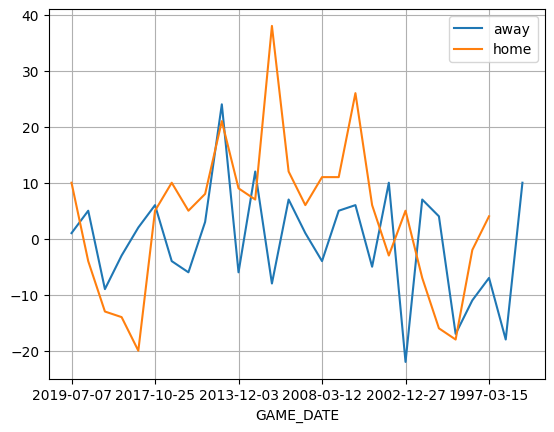

In [19]:
fig, ax = plt.subplots()

games_away.plot(x='GAME_DATE',y='PLUS_MINUS', ax=ax)
games_home.plot(x='GAME_DATE',y='PLUS_MINUS', ax=ax)
ax.legend(["away", "home"])
ax.grid()

plt.show()

In [20]:
# Write your code below and press Shift+Enter to execute
print(f"Mean of Games played home: {games_home['PTS'].mean()}")
print(f"Mean of Games played away: {games_home['PTS'].mean()}")

Mean of Games played home: 106.8076923076923
Mean of Games played away: 106.8076923076923
